In [1]:
# imports
import sys
import numpy as np
import pandas as pd
import scipy.linalg as slin
import scipy.stats as stats

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.style.use('scifigs.mplstyle')

sys.path.append('helpers/')
import helpers.pcca_fa.pcca_fa_mdl as pf
from dual_pfc_funcs import getParams, load_dict, get_top_vec, nansem

# params
SAVE_FIG = False
data_path = 'preprocessed_data/'
params = getParams()
subjects, symbols, color_map = params['subjects'], params['markers'], params['color_map']

In [2]:
pccafa = {}
for sub in subjects:
    pccafa = {**pccafa, **load_dict(data_path + sub + '_pccafa_cv15dim.pkl')}
fnames = pccafa.keys()

df = pd.DataFrame(columns=['SessionName','PctPosWx','PctPosWy','PctPosLx','PctPosLy','BadFlipW'])
for i, (sess, curr_dat) in enumerate(pccafa.items()):
    p = curr_dat['params']
    mdl = pf.pcca_fa()
    mdl.set_params(p)
    
    _,pct_wx,flipx = get_top_vec(p['W_x'],orth=True)
    _,pct_wy,flipy = get_top_vec(p['W_y'],orth=True)
    _,pct_lx,_ = get_top_vec(p['L_x'])
    _,pct_ly,_ = get_top_vec(p['L_y'])
    bad_flip = flipx ^ flipy # only counts sessions where one across-area vec was flipped without the other

    df2 = {'SessionName':sess,'PctPosWx':pct_wx*100,'PctPosWy':pct_wy*100,'PctPosLx':pct_lx*100,'PctPosLy':pct_ly*100,'BadFlipW':bad_flip}
    df.loc[len(df)] = df2
# df

print('Number of bad flips: {} of {}'.format(df['BadFlipW'].sum(), len(df)))

Number of bad flips: 16 of 42


/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_26811/1273639069.py:32: RuntimeWarning: Mean of empty slice
  ax[j].errorbar(np.arange(curr_x.shape[1])+1, np.nanmean(curr_x,axis=0), yerr=nansem(curr_x,axis=0), fmt='-', marker=sym, color=color_map['across'], ms=ms)
/Users/mmcdonnell/opt/miniconda3/envs/pccafa/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_26811/1273639069.py:35: RuntimeWarning: Mean of empty slice
  ax[j].errorbar(np.arange(curr_y.shape[1])+1, np.nanmean(curr_y,axis=0), yerr=nansem(curr_y,axis=0), fmt='--', mfc='none', marker=sym, color=color_map['across'], ms=ms)
/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_26811/1273639069.py:49: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the f

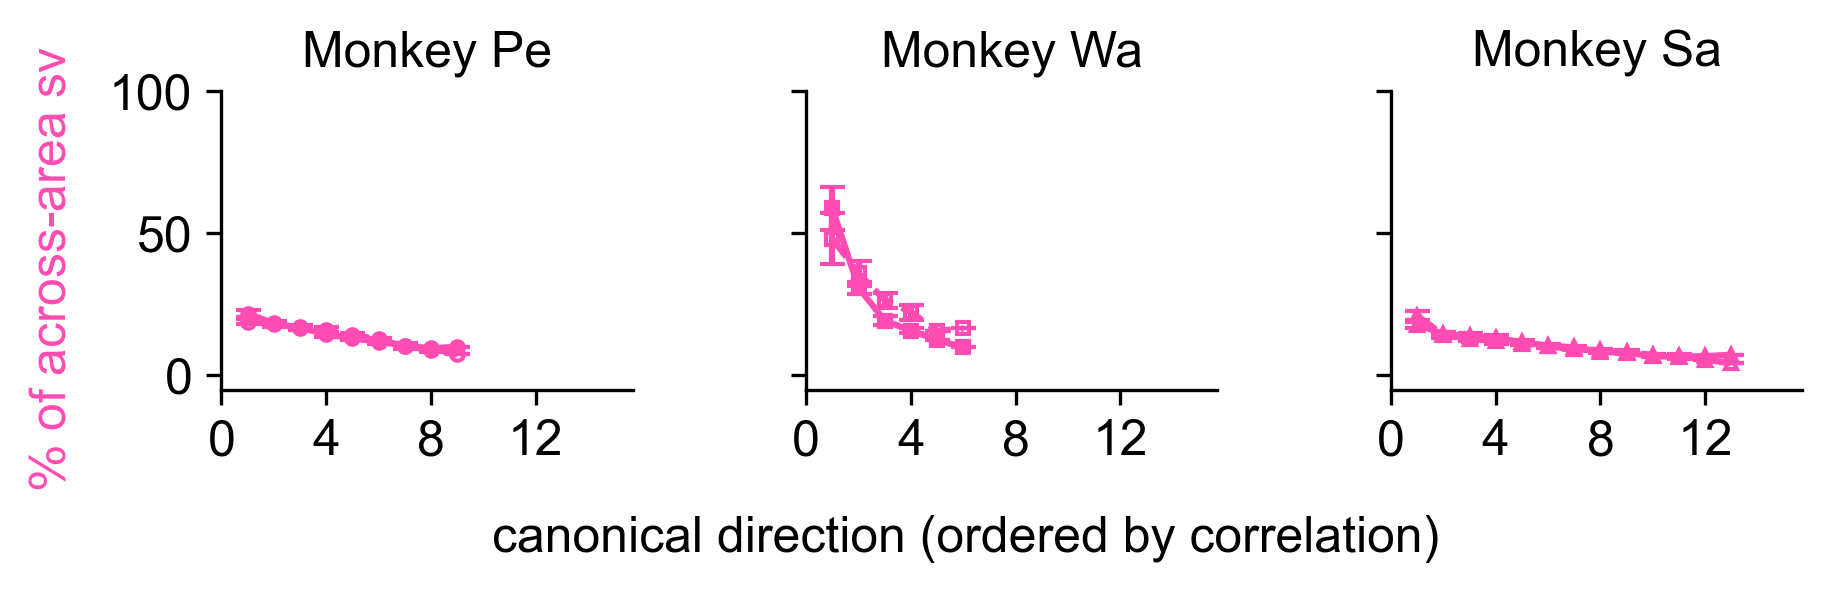

In [3]:
# "eigenspectra"
max_dim = 15
prop_var_across_x = np.full(shape=(len(df),max_dim),fill_value=np.nan)
prop_var_across_y= np.full(shape=(len(df),max_dim),fill_value=np.nan)

for i, (sess, curr_dat) in enumerate(pccafa.items()):
    p = curr_dat['params'].copy()
    mdl = pf.pcca_fa()
    mdl.set_params(p)
    (canon_dir_x,canon_dir_y),_ = mdl.get_canonical_directions()
    curr_zdim = p['zDim']

    for j in range(curr_zdim):
        prop_var_across_x[i,j] = canon_dir_x[:,j,np.newaxis].T @ (p['W_x'] @ p['W_x'].T) @ canon_dir_x[:,j,np.newaxis]
        prop_var_across_y[i,j] = canon_dir_y[:,j,np.newaxis].T @ (p['W_y'] @ p['W_y'].T) @ canon_dir_y[:,j,np.newaxis]

    # turn into proportion
    prop_var_across_x[i,:] = prop_var_across_x[i,:] / np.nansum(prop_var_across_x[i,:])
    prop_var_across_y[i,:] = prop_var_across_y[i,:] / np.nansum(prop_var_across_y[i,:])

fig,ax = plt.subplots(1,3,sharex=True,sharey=True,figsize=(6.5,2))
fig.tight_layout(pad=2.5)
fig.supylabel('$\%$ of across-area sv',color=color_map['across'])
fig.supxlabel('canonical direction (ordered by correlation)')

ms = 3
for j,(sub,sym) in enumerate(zip(subjects,symbols)):
    sub_prefix = sub[:2].title()
    filt = [sub_prefix in s for s in df['SessionName']] # same order as array

    curr_x = prop_var_across_x[filt,:] * 100
    ax[j].errorbar(np.arange(curr_x.shape[1])+1, np.nanmean(curr_x,axis=0), yerr=nansem(curr_x,axis=0), fmt='-', marker=sym, color=color_map['across'], ms=ms)
    
    curr_y = prop_var_across_y[filt,:] * 100
    ax[j].errorbar(np.arange(curr_y.shape[1])+1, np.nanmean(curr_y,axis=0), yerr=nansem(curr_y,axis=0), fmt='--', mfc='none', marker=sym, color=color_map['across'], ms=ms)

    ax[j].set_title('Monkey {}'.format(sub_prefix))

ax[0].set_ylim([-5,100])
ax[0].set_xticks(np.arange(0,max_dim,4))
ax[0].set_yticks([0,50,100])
ax[0].set_xlim((0.0, 15.7))

if SAVE_FIG:
    pdf = PdfPages('figs/eig_across.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_26811/848780217.py:31: RuntimeWarning: Mean of empty slice
  ax[j].errorbar(np.arange(curr_x.shape[1])+1, np.nanmean(curr_x,axis=0), yerr=nansem(curr_x,axis=0), fmt='-', marker=sym, color=color_map['within2'], ms=ms)
/Users/mmcdonnell/opt/miniconda3/envs/pccafa/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_26811/848780217.py:34: RuntimeWarning: Mean of empty slice
  ax[j].errorbar(np.arange(curr_y.shape[1])+1, np.nanmean(curr_y,axis=0), yerr=nansem(curr_y,axis=0), fmt='--', mfc='none', marker=sym, color=color_map['within1'], ms=ms)
/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_26811/848780217.py:48: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the fi

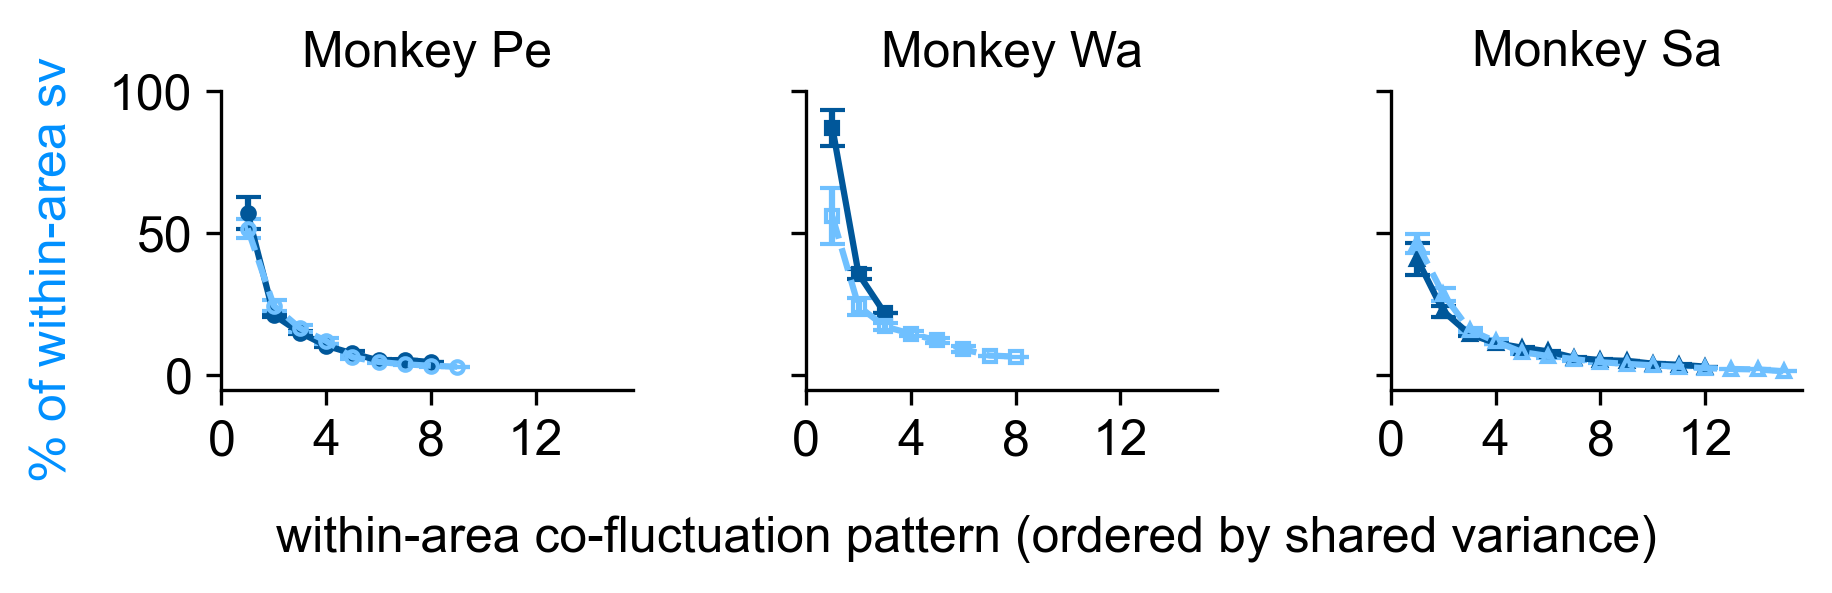

In [22]:
# eigenspectra
max_dim = 15
prop_var_within_x = np.full(shape=(len(df),max_dim),fill_value=np.nan)
prop_var_within_y = np.full(shape=(len(df),max_dim),fill_value=np.nan)

for i, (sess, curr_dat) in enumerate(pccafa.items()):
    p = curr_dat['params'].copy()

    # L_x
    vals = slin.svdvals(p['L_x'] @ p['L_x'].T) # eigenvalues
    total_var = np.trace(p['L_x'] @ p['L_x'].T)
    prop_var_within_x[i,:p['zxDim']] = vals[:p['zxDim']] / total_var

    # L_y
    vals = slin.svdvals(p['L_y'] @ p['L_y'].T) # eigenvalues
    total_var = np.trace(p['L_y'] @ p['L_y'].T)
    prop_var_within_y[i,:p['zyDim']] = vals[:p['zyDim']] / total_var


fig,ax = plt.subplots(1,3,sharex=True,sharey=True,figsize=(6.5,2))
fig.tight_layout(pad=2.5)
fig.supylabel('$\%$ of within-area sv',color=color_map['within'])
fig.supxlabel('within-area co-fluctuation pattern (ordered by shared variance)')

ms = 3
for j,(sub,sym) in enumerate(zip(subjects,symbols)):
    sub_prefix = sub[:2].title()
    filt = [sub_prefix in s for s in df['SessionName']] # same order as array

    curr_x = prop_var_within_x[filt,:] * 100
    ax[j].errorbar(np.arange(curr_x.shape[1])+1, np.nanmean(curr_x,axis=0), yerr=nansem(curr_x,axis=0), fmt='-', marker=sym, color=color_map['within2'], ms=ms)
    
    curr_y = prop_var_within_y[filt,:] * 100
    ax[j].errorbar(np.arange(curr_y.shape[1])+1, np.nanmean(curr_y,axis=0), yerr=nansem(curr_y,axis=0), fmt='--', mfc='none', marker=sym, color=color_map['within1'], ms=ms)

    ax[j].set_title('Monkey {}'.format(sub_prefix))

ax[0].set_ylim([-5,100])
ax[0].set_xticks(np.arange(0,max_dim,4))
ax[0].set_yticks([0,50,100])
ax[0].set_xlim((0.0, 15.7))

if SAVE_FIG:
    pdf = PdfPages('figs/eig_within.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

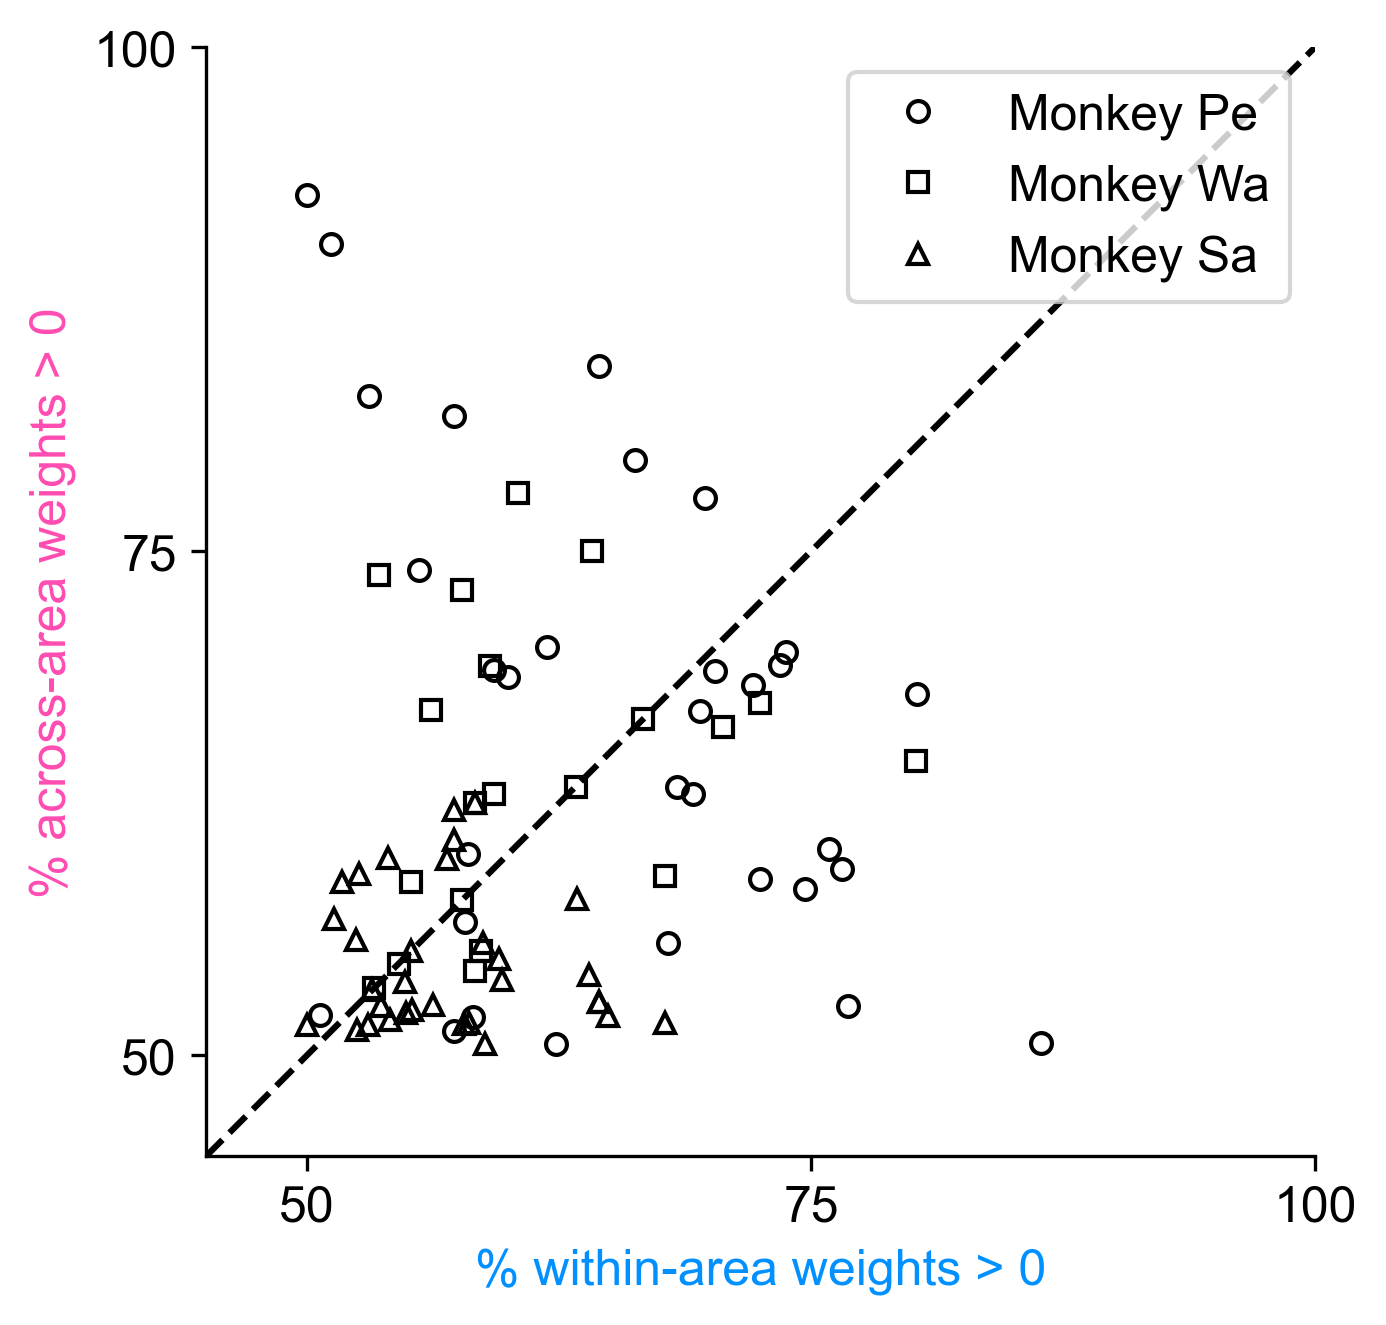

In [25]:
# loop through each monkey
fig,ax = plt.subplots()

for sub,sym in zip(subjects,symbols):
    sub_prefix = sub[:2].title()
    filt = [sub_prefix in s for s in df['SessionName']]
    tmp_df = df[filt]
    ax.plot(tmp_df['PctPosLx'], tmp_df['PctPosWx'], color='black', marker=sym, markersize=5, fillstyle='none', ls='', label='Monkey {}'.format(sub_prefix))
    ax.plot(tmp_df['PctPosLy'], tmp_df['PctPosWy'], color='black', marker=sym, markersize=5, fillstyle='none', ls='')

# make plots pretty and display them
lims = [45,100]
ticks = np.arange(50,105,25)
ax.legend(loc='upper right')
ax.set_xlabel('% within-area weights > 0', color=color_map['within'])
ax.set_ylabel('% across-area weights > 0', color=color_map['across'])
ax.plot(lims,lims,'k--')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_aspect('equal')

if SAVE_FIG:
    pdf = PdfPages('figs/pos_weights_all_sess.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

In [26]:
# statistics
alpha = 0.01

# test if across and within are different across all monkeys
pct_within = np.concatenate((df['PctPosLx'], df['PctPosLy']))
pct_across = np.concatenate((df['PctPosWx'], df['PctPosWy']))
print('pct pos: across={:.3f} +/- {:.3f} s.e.m., within={:.3f} +/- {:.3f} s.e.m.'.format(np.mean(pct_across),stats.sem(pct_across),pct_within.mean(),stats.sem(pct_within)))

_,p = stats.ttest_rel(pct_across,pct_within,alternative='two-sided')
print()
print('Across different than within?')
print('Pooled, pct pos: {}, p = {:5f}'.format(p<alpha,p))
print()
for sub in subjects:
    sub_prefix = sub[:2].title()
    filt = [sub_prefix in s for s in df['SessionName']]
    tmp_df = df[filt]

    pct_within = np.concatenate((tmp_df['PctPosLx'], tmp_df['PctPosLy']))
    pct_across = np.concatenate((tmp_df['PctPosWx'], tmp_df['PctPosWy']))

    # test if across and within are different for this monkey
    _,p = stats.ttest_rel(pct_across,pct_within,alternative='two-sided')
    print('Monkey {:s}, pct pos: {}, p = {:5f}'.format(sub_prefix,p<alpha,p))

pct pos: across=61.424 +/- 1.081 s.e.m., within=61.370 +/- 0.887 s.e.m.

Across different than within?
Pooled, pct pos: False, p = 0.968197

Monkey Pe, pct pos: False, p = 0.798890
Monkey Wa, pct pos: False, p = 0.193812
Monkey Sa, pct pos: False, p = 0.034716
